In [2]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Embedding, LSTM, Dropout, GlobalAveragePooling1D,GlobalMaxPooling1D,MaxPooling1D,Conv1D
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import re
import pickle

In [4]:
data = pd.read_csv('/content/Reviews.csv',engine="python",quotechar='"')

In [5]:
data.head()

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wid...


In [6]:
data["sentiment"]=data["Score"].apply(lambda x:1 if x>=4 else 0)

In [7]:
def clean_text(text):
  text=str(text).lower()
  text=re.sub(r'[^a-zA-Z\s]','',text)
  text=re.sub(r'\s+'," ",text).strip()
  return text

data["cleaned_text"]=data["Text"].apply(clean_text)

In [8]:
data.head()

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text,sentiment,cleaned_text
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...,1,i have bought several of the vitality canned d...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...,0,product arrived labeled as jumbo salted peanut...
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...,1,this is a confection that has been around a fe...
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...,0,if you are looking for the secret ingredient i...
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wid...,1,great taffy at a great price there was a wide ...


In [9]:
X=data["cleaned_text"]
y=data["sentiment"]

In [10]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [11]:
# Токенезируем данные
vocab_size = 10000  # Указываем размер нашего словаря
max_length = 80    # Максимальное количество токенов в предложении
trunc_type = 'post' # Удаляем части предложений, которые идут после лимита
padding_type = 'post' # Добавляем текст в конец предложений что бы достич лимита
oov_tok = '<OOV>'   # Заменям слова, которых нет в словаре данным токеном

tokenizer = Tokenizer(num_words=vocab_size,oov_token=oov_tok)
tokenizer.fit_on_texts(X)

In [13]:
# Токенезируем текст
train_seq=tokenizer.texts_to_sequences(X_train)
test_seq=tokenizer.texts_to_sequences(X_test)
# Добиваем размер предложений до нашего лимита
train_seq=pad_sequences(train_seq,maxlen=max_length, padding=padding_type, truncating=trunc_type)
test_seq=pad_sequences(test_seq,maxlen=max_length, padding=padding_type, truncating=trunc_type)

In [17]:
X_train[25]

'product received is as advertisedbr br a hrefhttpwwwamazoncomgpproductbgvisjmtwizzlers strawberry ounce bags pack of a'

In [16]:
train_seq[25]

array([   3, 2220,   10,   57,   31,   26,    2, 4451,    3,   53,   12,
       2949,    5,  159,  169,  418,    7,   21,  489,   16,  216,  121,
        905,    4,   21,   42,    3,  584,   11,  414,   11,    2,  210,
        449,    3,   21,  377,   74,   80,   21,  363,    5,  356, 1192,
          8, 1464,   83,   88,   18, 2511,    8,  189,   37,   19,   26,
       1464,   28, 4953,   20,  615,    4, 3615,    2,  378, 5080,  497,
        313,   17,   62,  735,    4,   20,  308,    8,    1,    3,   21,
        968,   16,    2], dtype=int32)

In [28]:
model=Sequential([
    Embedding(input_dim=vocab_size,output_dim=100,input_length=max_length),
    Conv1D(filters=128,kernel_size=5,padding="valid",activation="relu"),
    MaxPooling1D(pool_size=4),
    Dense(64,activation="relu"),
    Dropout(0.5),
    GlobalMaxPooling1D(),
    Dense(1,activation="sigmoid")
])

model.compile(
    loss="binary_crossentropy",
    optimizer="adam",
    metrics=['accuracy',tf.keras.metrics.Precision(),tf.keras.metrics.Recall()]
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [29]:
early_estopping=tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

In [30]:
history=model.fit(
    train_seq,y_train,
    epochs=20,
    batch_size=32,
    validation_data=(test_seq,y_test),
    callbacks=[early_estopping],
    verbose=1
)

Epoch 1/20
14212/14212 ━━━━━━━━━━━━━━━━━━━━ 566s 40ms/step - accuracy: 0.8963 - loss: 0.2525 - precision_1: 0.9169 - recall_1: 0.9534 - val_accuracy: 0.9038 - val_loss: 0.2398 - val_precision_1: 0.9048 - val_recall_1: 0.9803
Epoch 2/20
14212/14212 ━━━━━━━━━━━━━━━━━━━━ 618s 39ms/step - accuracy: 0.9279 - loss: 0.1873 - precision_1: 0.9448 - recall_1: 0.9639 - val_accuracy: 0.9225 - val_loss: 0.2218 - val_precision_1: 0.9500 - val_recall_1: 0.9511
Epoch 3/20
14212/14212 ━━━━━━━━━━━━━━━━━━━━ 558s 39ms/step - accuracy: 0.9448 - loss: 0.1475 - precision_1: 0.9586 - recall_1: 0.9712 - val_accuracy: 0.9166 - val_loss: 0.2301 - val_precision_1: 0.9601 - val_recall_1: 0.9322
Epoch 4/20
14212/14212 ━━━━━━━━━━━━━━━━━━━━ 566s 40ms/step - accuracy: 0.9579 - loss: 0.1153 - precision_1: 0.9687 - recall_1: 0.9775 - val_accuracy: 0.9237 - val_loss: 0.2017 - val_precision_1: 0.9385 - val_recall_1: 0.9658
Epoch 5/20
14212/14212 ━━━━━━━━━━━━━━━━━━━━ 556s 39ms/step - accuracy: 0.9680 - loss: 0.0882 - preci

In [31]:
y_test

,sentiment
165256,1
231465,1
427827,0
433954,0
70260,1
...,...
205323,1
95366,1
75510,1
381923,1


In [32]:
# Оцениваем тестовые данные
loss, accuracy, precision, recall = model.evaluate(test_seq, y_test)
print(f"Test Accuracy: {accuracy:.4f}")
print(f"Test Precision: {precision:.4f}")
print(f"Test Recall: {recall:.4f}")

# Делаем предсказания
y_pred = (model.predict(test_seq) > 0.5).astype("int32")


print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Negative', 'Positive']))


print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

3553/3553 ━━━━━━━━━━━━━━━━━━━━ 37s 10ms/step - accuracy: 0.9237 - loss: 0.2017 - precision_1: 0.9385 - recall_1: 0.9658
Test Accuracy: 0.9237
Test Precision: 0.9385
Test Recall: 0.9658
3553/3553 ━━━━━━━━━━━━━━━━━━━━ 31s 9ms/step

Classification Report:
              precision    recall  f1-score   support

    Negative       0.86      0.77      0.81     24666
    Positive       0.94      0.97      0.95     89025

    accuracy                           0.92    113691
   macro avg       0.90      0.87      0.88    113691
weighted avg       0.92      0.92      0.92    113691


Confusion Matrix:
[[19033  5633]
 [ 3043 85982]]


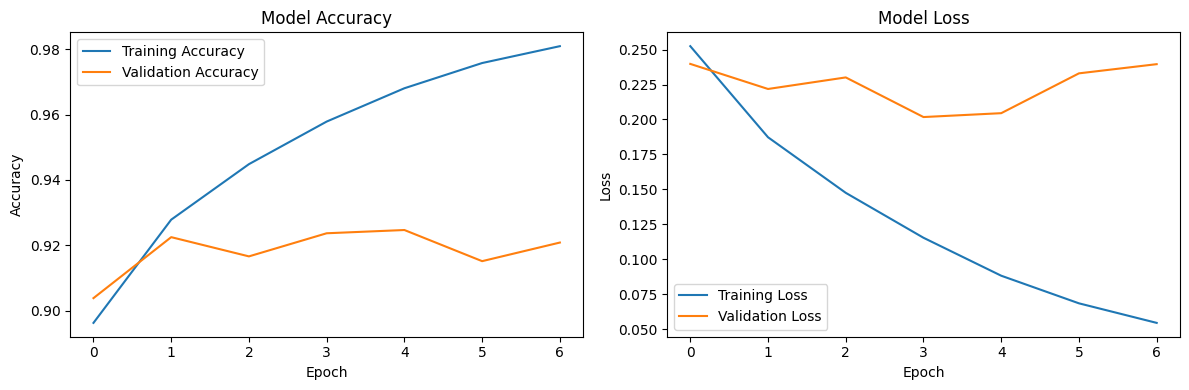

In [33]:
# Строим график обучения
def plot_training_history(history):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    ax1.plot(history.history['accuracy'], label='Training Accuracy')
    ax1.plot(history.history['val_accuracy'], label='Validation Accuracy')
    ax1.set_title('Model Accuracy')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Accuracy')
    ax1.legend()

    ax2.plot(history.history['loss'], label='Training Loss')
    ax2.plot(history.history['val_loss'], label='Validation Loss')
    ax2.set_title('Model Loss')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Loss')
    ax2.legend()

    plt.tight_layout()
    plt.show()

plot_training_history(history)

In [23]:
model.save('sentience_analize.keras')

In [24]:
model.save_weights('sentience_analize.weights.h5')

In [ ]:
#сохранение
with open('tokenizer.pickle', 'wb') as handle:
    pickle.dump(tokenizer, handle, protocol=pickle.HIGHEST_PROTOCOL)

# загрузка
with open('tokenizer.pickle', 'rb') as handle:
    tokenizer = pickle.load(handle)